In [2]:
# Преоразовать существующий код для распознавания последовательности рукописных символов в текст.
# Написать генератор произвольной последовательности рукописных символов.

# ГЕНЕРАЦИЯ НАБОРА ДАННЫХ
# Сгенерировать набор текстовых строк из допустимых символов.
# Каждому набору поставить в соотвествие массив изоражений соответствующих символов.
# Добавить пробелы для разделения слов, символы пробелов не использовать во время классификации.


# КЛАССИФИКАЦИЯ (k ближайших соседей) (пример AIM practice 2)
# Часть символов оставить для обучения классификатора . Остальные  классифицировать
# по аналогии с примером mnist с прошлого занятия. Т.е. преобразовывать изображение в вектор.
# Выбрать оптимальный классификатор в зависимости от k- количество соседей.
# Метрика для измерения точности классификации, и выбора оптимального классификатора относительно параметра k - accuracy.

# РАСПОЗНАВАНИЕ
# заменить inf_net на последовательное применение следующих шагов:
# 1. генерация изображения с последовательностью символов
# 2. Выделение объектов оставляете как есть.
# 3. Примернить k-nn для решения задачи классификации. 
# 4. Вывести результат

In [21]:
import zipfile
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt
from io import BytesIO
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report


In [27]:
ZIP_PATH = "data.zip"
zf = zipfile.ZipFile(ZIP_PATH, "r")

characters = [")","(","+","-",",","0","1","2","3","4","5","6","7","8","9","X","h","t","*","w","y"]


In [22]:
def generate_string(length):
    return ''.join(random.choice(characters) for _ in range(length))


In [23]:
def list_images_in_zip(symbol):
    folder = 'times' if symbol == '*' else symbol
    return [name for name in zf.namelist()
            if name.startswith(folder + "/") and name.endswith(".jpg")]


In [24]:
def read_image_from_zip(path):
    data = zf.read(path)
    img = Image.open(BytesIO(data)).convert("RGB")
    return np.array(img)


In [25]:
def images_from_string(string):
    images = []
    paths = []

    for ch in string:
        files = list_images_in_zip(ch)
        chosen = random.choice(files)
        paths.append(chosen)
        images.append(read_image_from_zip(chosen))

    return images, paths


In [28]:
# Демонстрация
str_size = 10
random_str = generate_string(str_size)
print("Сгенерированная строка:", random_str)

images, paths = images_from_string(random_str)
for p in paths:
    print(p)


Сгенерированная строка: 1h0h,,467y
1/1_6551.jpg
h/exp64573.jpg
0/0_16942.jpg
h/exp66559.jpg
,/exp57241.jpg
,/,_104605.jpg
4/4_68416.jpg
6/exp50187.jpg
7/exp97014.jpg
y/exp44358.jpg


In [29]:
def combine_images(images, spacing=30):
    spaced = []
    for i, img in enumerate(images):
        spaced.append(img)
        if i != len(images) - 1:
            spacer = np.ones((img.shape[0], spacing, 3), dtype=np.uint8) * 255
            spaced.append(spacer)

    return cv2.cvtColor(cv2.hconcat(spaced), cv2.COLOR_BGR2RGB)


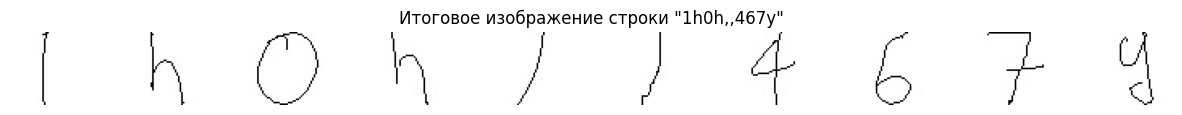

In [30]:
str_image = combine_images(images, spacing=30)

plt.figure(figsize=(15, 2))
plt.imshow(str_image)
plt.axis('off')
plt.title(f'Итоговое изображение строки "{random_str}"')
plt.show()


In [31]:
def normalize_symbol(symbol, size=45):
    h, w = symbol.shape
    canvas = np.ones((size, size), dtype=np.uint8) * 255

    if h > size or w > size:
        scale = (size - 2) / max(h, w)
        symbol = cv2.resize(symbol, (int(w*scale), int(h*scale)))

    h, w = symbol.shape
    y0 = (size - h) // 2
    x0 = (size - w) // 2

    canvas[y0:y0+h, x0:x0+w] = symbol
    return cv2.bitwise_not(canvas)


In [32]:
def extract_symbols(image, threshold=20):
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    _, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY_INV)

    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
    closed = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)

    contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contours = sorted(contours, key=lambda c: cv2.boundingRect(c)[0])

    symbols = []
    for c in contours:
        x, y, w, h = cv2.boundingRect(c)
        if w * h > threshold:
            crop = gray[y:y+h, x:x+w]
            symbols.append(normalize_symbol(crop))

    return symbols


Кол-во символов: 10


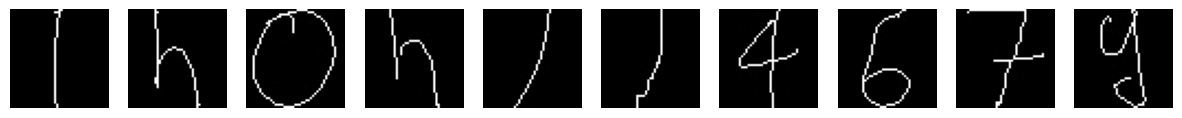

In [33]:
symbols = extract_symbols(str_image)
print("Кол-во символов:", len(symbols))

plt.figure(figsize=(15,2))
for i, s in enumerate(symbols):
    plt.subplot(1, len(symbols), i+1)
    plt.imshow(s, cmap='gray')
    plt.axis('off')
plt.show()


In [34]:
def load_data_from_zip():
    X, y = [], []

    for ch in characters:
        files = list_images_in_zip(ch)
        print(f"Символ '{ch}': {len(files)} образцов")

        for f in files:
            img = read_image_from_zip(f)
            gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
            norm = normalize_symbol(gray)
            X.append(norm.flatten())
            y.append(ch)

    return np.array(X), np.array(y)


In [35]:
X_all, y_all = load_data_from_zip()
print("Всего образцов:", len(X_all))


Символ ')': 14355 образцов
Символ '(': 14294 образцов
Символ '+': 25112 образцов
Символ '-': 33997 образцов
Символ ',': 1906 образцов
Символ '0': 6914 образцов
Символ '1': 26520 образцов
Символ '2': 26141 образцов
Символ '3': 10909 образцов
Символ '4': 7396 образцов
Символ '5': 3545 образцов
Символ '6': 3118 образцов
Символ '7': 2909 образцов
Символ '8': 3089 образцов
Символ '9': 628 образцов
Символ 'X': 26594 образцов
Символ 'h': 1464 образцов
Символ 't': 3274 образцов
Символ '*': 3251 образцов
Символ 'w': 556 образцов
Символ 'y': 9340 образцов
Всего образцов: 225312


In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.1, stratify=y_all, random_state=42
)

models = {}
accs = {}

for k in [1, 3, 5, 7]:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    models[k] = model
    accs[k] = acc
    print(f"KNN (k={k}) accuracy = {acc:.2%}")

best_k = max(accs, key=accs.get)
best_model = models[best_k]
print(f"Лучший k = {best_k}")


KNN (k=1) accuracy = 99.55%
KNN (k=3) accuracy = 95.84%
KNN (k=5) accuracy = 80.85%
KNN (k=7) accuracy = 74.46%
Лучший k = 1


In [37]:
def predict_symbols(model, symbols):
    return [model.predict([s.flatten()])[0] for s in symbols]


In [38]:
recognized = predict_symbols(best_model, symbols)
recognized_str = ''.join(recognized)

print("Оригинальная строка:  ", random_str)
print("Распознанная строка:", recognized_str)

print(classification_report(list(random_str), recognized, zero_division=0))

acc = accuracy_score(list(random_str), recognized)
print(f"Точность: {acc:.1%}")


Оригинальная строка:   1h0h,,467y
Распознанная строка: 1h0h,,467y
              precision    recall  f1-score   support

           ,       1.00      1.00      1.00         2
           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1
           4       1.00      1.00      1.00         1
           6       1.00      1.00      1.00         1
           7       1.00      1.00      1.00         1
           h       1.00      1.00      1.00         2
           y       1.00      1.00      1.00         1

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10

Точность: 100.0%


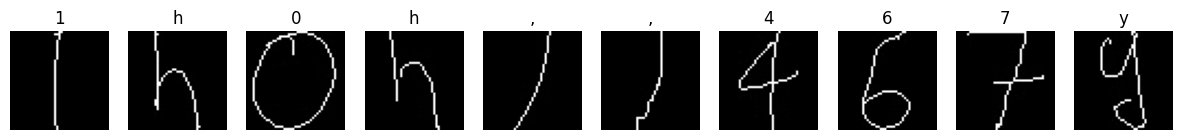

In [39]:
plt.figure(figsize=(15,2))
for i, s in enumerate(symbols):
    plt.subplot(1, len(symbols), i+1)
    plt.imshow(s, cmap='gray')
    plt.title(recognized[i])
    plt.axis('off')
plt.show()
